# 3.1 — Основные метрики и калибровка

**Папка 3 «Оценка», подноутбук 1.** Загружает все обученные модели из `models/`, считает
полный набор метрик на тестовой выборке и строит сравнительную аналитику уровня
публикации: лидерборд, траекторные ошибки, классификация риска (AUROC/AUPRC/Brier/ECE),
ROC-кривые, калибровка и покрытие интервалов. Все рисунки и таблицы — на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table
from liquefaction_ai.models import CatBoostBaseline

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from liquefaction_ai.viz import bar, calibration_plot, grouped_bar, lines

models, predictions, sample_tables, rows = {}, {}, {}, []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name)
    disp = hp["display_name"]
    out = collect_outputs(model, test, config, device)
    met, sample_df = compute_metrics(disp, out, test, config)
    models[disp] = model; predictions[disp] = out; sample_tables[disp] = sample_df; rows.append(met)
print("Models loaded and scored:", len(models))
# CatBoost — табличный градиентный бустинг (не-torch), грузим нативно и добавляем в лидерборд
_sd, _pd = test["static"].shape[1], test["prefix_summary"].shape[1]
_cb = CatBoostBaseline(_sd, _pd).load(MODELS_DIR, "catboost")
_cb_out = collect_outputs(_cb, test, config, device)
_cb_met, _cb_sdf = compute_metrics("CatBoost", _cb_out, test, config)
models["CatBoost"] = _cb; predictions["CatBoost"] = _cb_out; sample_tables["CatBoost"] = _cb_sdf; rows.append(_cb_met)
print("CatBoost added | total models:", len(models))

Models loaded and scored: 13
CatBoost added | total models: 14


## Leaderboard

In [2]:
leaderboard = pd.DataFrame(rows).sort_values(["Traj_RMSE", "Brier"], na_position="last").reset_index(drop=True)
display(english_metric_table(leaderboard).round(4))
leaderboard.to_csv(REPO_ROOT / "results" / "tables" / "full_leaderboard.csv", index=False)
print("saved results/tables/full_leaderboard.csv")

# === Раздельные лидерборды (честность сравнения) ===
# Risk-only модели (CatBoost, FT-Transformer, MLP-Risk) не выдают траекторию/CRR — их сведение
# в один лидерборд с физическими моделями вводит в заблуждение. Делим на два:
#   • leaderboard_risk.csv        — все модели, только метрики риска/события;
#   • leaderboard_trajectory.csv  — только state-space/physics модели (есть траектория PPR).
leaderboard["Produces_Trajectory"] = leaderboard["Traj_RMSE"].notna().astype(int)
_tab = REPO_ROOT / "results" / "tables"
_risk_cols = ["model", "AUROC", "AUPRC", "Brier", "ECE",
              "N_liq_logMAE", "N_liq_MAE", "N_liq_n_observed", "Produces_Trajectory"]
risk_lb = (leaderboard[[c for c in _risk_cols if c in leaderboard.columns]]
           .sort_values("AUROC", ascending=False).reset_index(drop=True))
risk_lb.to_csv(_tab / "leaderboard_risk.csv", index=False)
_traj_cols = ["model", "Traj_RMSE", "Traj_CRPS", "Calibration_Error", "Coverage_90",
              "Physics_Violation_Rate", "CRR_RMSE", "N_CRR_test", "N_CRR_objects",
              "N_liq_logMAE", "N_liq_n_observed"]
traj_lb = (leaderboard[leaderboard["Produces_Trajectory"] == 1][[c for c in _traj_cols if c in leaderboard.columns]]
           .sort_values("Traj_RMSE").reset_index(drop=True))
traj_lb.to_csv(_tab / "leaderboard_trajectory.csv", index=False)
print(f"saved leaderboard_risk.csv ({len(risk_lb)} моделей) и leaderboard_trajectory.csv ({len(traj_lb)} моделей)")
print(f"CRR-метрика опирается на N_CRR_test={int(leaderboard['N_CRR_test'].dropna().max() or 0)} образцов "
      f"из N_CRR_objects={int(leaderboard['N_CRR_objects'].dropna().max() or 0)} объектов — малая выборка.")

,Model,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,Onset_Timing_Bias_cyc,...,Trajectory RMSE (liquefied),"Trajectory RMSE (no-liq, stabilized)","Trajectory RMSE (no-liq, not stabilized)",Trajectory RMSE (balanced over states),Trajectory RMSE (worst state),Post-prefix RMSE (liquefied),"Post-prefix RMSE (no-liq, stabilized)","Post-prefix RMSE (no-liq, not stabilized)",Post-prefix RMSE (balanced over states),Post-prefix RMSE (worst state)
0,RealNVP,330.3340,530.0575,0.5310,0.7576,168,0.8333,146.9173,0.5233,-2.6258,...,0.0770,0.0930,NaN,0.0850,0.0930,0.0726,0.0921,NaN,0.0823,0.0921
1,Neural Spline Flow,417.8363,584.1985,0.5391,0.7418,168,0.7882,146.3218,0.6279,-25.7323,...,0.1433,0.0532,NaN,0.0982,0.1433,0.1336,0.0545,NaN,0.0940,0.1336
2,DPI-Flow,23.2449,61.6108,0.1229,0.2100,168,0.2381,39.6134,0.2209,6.4096,...,0.1186,0.1278,NaN,0.1232,0.1278,0.0948,0.1282,NaN,0.1115,0.1282
3,DPI-EVT,112.4632,330.4693,0.2922,0.4706,168,0.5075,88.1483,0.6279,-38.4419,...,0.1352,0.1508,NaN,0.1430,0.1508,0.1119,0.1500,NaN,0.1310,0.1500
4,GRU,1361.7539,1810.0742,1.6886,1.9544,168,1.3981,201.1682,0.0698,221.0014,...,0.1556,0.2473,NaN,0.2015,0.2473,0.1204,0.2517,NaN,0.1861,0.2517
5,Transformer,1516.1060,2054.4031,2.8597,3.0612,168,1.9314,165.6929,0.7558,-124.4206,...,0.1418,0.3239,NaN,0.2328,0.3239,0.1165,0.3396,NaN,0.2281,0.3396
6,LSTM,1545.9420,1569.3879,1.8769,2.3593,168,2.8254,1361.6156,0.0000,1379.0233,...,0.1608,0.3399,NaN,0.2504,0.3399,0.1200,0.3390,NaN,0.2295,0.3390
7,PINN,1430.9147,1962.1826,1.9354,2.2038,168,1.0721,124.2655,0.6860,-78.6622,...,0.1474,0.3917,NaN,0.2696,0.3917,0.1161,0.3940,NaN,0.2551,0.3940
8,TCN,1384.1849,1855.8773,1.7302,1.9924,168,1.3225,181.0807,0.1628,170.4096,...,0.1656,0.3924,NaN,0.2790,0.3924,0.1281,0.4046,NaN,0.2663,0.4046
9,DeepState,1410.1318,1726.5157,1.8466,2.1497,168,1.9355,454.6195,0.0116,487.1852,...,0.1232,0.5432,NaN,0.3332,0.5432,0.0994,0.5597,NaN,0.3295,0.5597


saved results/tables/full_leaderboard.csv
saved leaderboard_risk.csv (14 моделей) и leaderboard_trajectory.csv (11 моделей)
CRR-метрика опирается на N_CRR_test=71 образцов из N_CRR_objects=1 объектов — малая выборка.


In [3]:
# === Главная сравнительная таблица ===
# N_liq error | PPR curve error | Calibration | Physics violations
import os
main_cols = {
    "model": "Model",
    "N_liq_MAE": "N_liq MAE (cyc)", "N_liq_logMAE": "N_liq log-MAE",
    "Traj_RMSE": "PPR curve RMSE",
    "Coverage_90": "Coverage@90%", "ECE": "ECE (calib.)",
    "Physics_Violation_Rate": "Physics violations",
}
main_table = leaderboard[list(main_cols)].rename(columns=main_cols)
display(main_table.round(4))
os.makedirs(REPO_ROOT / "results" / "tables", exist_ok=True)
main_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "main_comparison.csv", index=False)
print("saved results/tables/main_comparison.csv")

,Model,N_liq MAE (cyc),N_liq log-MAE,PPR curve RMSE,Coverage@90%,ECE (calib.),Physics violations
0,RealNVP,330.3340,0.5310,0.0860,0.7690,0.0607,0.9881
1,Neural Spline Flow,417.8363,0.5391,0.1045,0.7434,0.0503,0.9226
2,DPI-Flow,23.2449,0.1229,0.1236,0.8528,0.0171,0.0000
3,DPI-EVT,112.4632,0.2922,0.1439,0.8089,0.0587,0.0000
4,GRU,1361.7539,1.6886,0.2104,0.9503,0.3206,0.4524
5,Transformer,1516.1060,2.8597,0.2572,0.7889,0.2620,0.0000
6,LSTM,1545.9420,1.8769,0.2731,0.8040,0.2041,0.0000
7,PINN,1430.9147,1.9354,0.3053,0.6636,0.3302,0.0000
8,TCN,1384.1849,1.7302,0.3100,0.7787,0.1598,0.0119
9,DeepState,1410.1318,1.8466,0.4088,0.8078,0.3406,0.0000


saved results/tables/main_comparison.csv


## Probabilistic & physics quality — structured models

Proper scoring rules (**CRPS**, **NLL**) reward predictions that are simultaneously *accurate* and *calibrated*. DPI-Flow, EVT-NeuralSSM and DPI-EVT emit a physical CRR(N) resistance curve. The current grouped leaderboard below is the source of truth for which model leads each metric; this section highlights that the structured models combine calibrated uncertainty, zero monotonicity violations and CRR capability, while black-box flows/RNNs routinely violate monotonicity.


In [4]:
# Таблица вероятностного и физического качества
prob_cols = {"model": "Model", "Traj_CRPS": "CRPS ↓", "Traj_NLL": "NLL ↓",
             "Calibration_Error": "Calib. err ↓", "Coverage_90": "Cov@90%",
             "Physics_Violation_Rate": "Physics viol. ↓", "CRR_RMSE": "CRR RMSE ↓"}
prob_table = leaderboard[list(prob_cols)].rename(columns=prob_cols)
display(prob_table.round(4))
prob_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "probabilistic_quality.csv", index=False)
print("saved results/tables/probabilistic_quality.csv")

,Model,CRPS ↓,NLL ↓,Calib. err ↓,Cov@90%,Physics viol. ↓,CRR RMSE ↓
0,RealNVP,0.0491,-0.3488,0.1247,0.7690,0.9881,NaN
1,Neural Spline Flow,0.0524,-0.0728,0.1592,0.7434,0.9226,NaN
2,DPI-Flow,0.0637,-0.8413,0.0397,0.8528,0.0000,0.2105
3,DPI-EVT,0.0784,-0.6088,0.0929,0.8089,0.0000,0.1523
4,GRU,0.1179,-0.1784,0.0557,0.9503,0.4524,NaN
5,Transformer,0.1453,0.0829,0.1096,0.7889,0.0000,NaN
6,LSTM,0.1538,0.1266,0.0924,0.8040,0.0000,NaN
7,PINN,0.1802,0.5746,0.2242,0.6636,0.0000,NaN
8,TCN,0.1748,0.2543,0.1031,0.7787,0.0119,NaN
9,DeepState,0.2059,0.3099,0.0962,0.8078,0.0000,NaN


saved results/tables/probabilistic_quality.csv


In [5]:
# Матрица возможностей: что вообще умеет каждая модель
PHYS_MODELS = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT"}
lb_idx = leaderboard.set_index("model")
cap = []
for disp, out in predictions.items():
    viol = float(lb_idx.loc[disp, "Physics_Violation_Rate"]) if disp in lb_idx.index else float("nan")
    cap.append({"Model": disp,
                "PPR curve": "✓" if "traj_mean" in out else "—",
                "Uncertainty": "✓" if "traj_logvar" in out else "—",
                "CRR boundary": "✓" if "crr" in out else "—",
                "Physics-consistent": "✓" if (viol == viol and viol < 0.05) else "—"})
capability = pd.DataFrame(cap).set_index("Model")
display(capability)

,PPR curve,Uncertainty,CRR boundary,Physics-consistent
Model,,,,
MLP-Risk,—,—,—,—
GRU,✓,✓,—,—
TCN,✓,✓,—,✓
LSTM,✓,✓,—,✓
Transformer,✓,✓,—,✓
FT-Transformer,—,—,—,—
PINN,✓,✓,—,✓
DeepState,✓,✓,—,✓
RealNVP,✓,✓,—,—


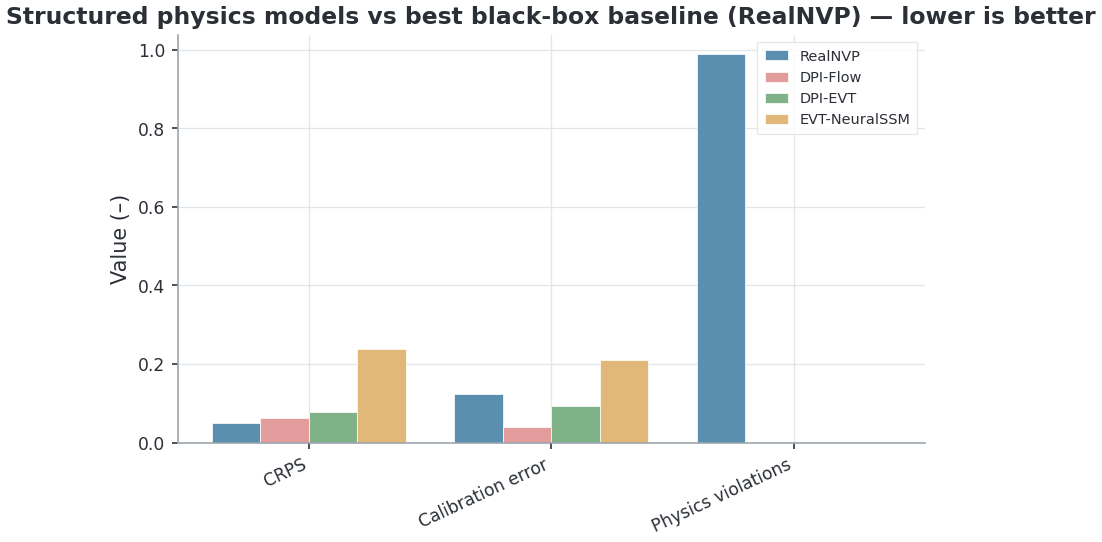

DPI-Flow: CRPS -29.8% vs RealNVP | calib.err 0.040 | physics-viol 0.000 | CRR RMSE 0.2105 (baselines: n/a)
EVT-NeuralSSM: CRPS -385.1% vs RealNVP | calib.err 0.211 | physics-viol 0.000 | CRR RMSE 0.2101 (baselines: n/a)
DPI-EVT: CRPS -59.8% vs RealNVP | calib.err 0.093 | physics-viol 0.000 | CRR RMSE 0.1523 (baselines: n/a)


In [6]:
# Наглядное сравнение структурных моделей с лучшим ЧЁРНЫМ ЯЩИКОМ
PHYS_INFORMED = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT", "PINN"}   # физически-информированные — не baseline
blackbox = leaderboard[~leaderboard["model"].isin(PHYS_INFORMED)].dropna(subset=["Traj_CRPS"])
best_base = blackbox.sort_values("Traj_CRPS").iloc[0]["model"]
sel = leaderboard[leaderboard["model"].isin(list(PHYS_MODELS) + [best_base])].set_index("model")
mets = ["Traj_CRPS", "Calibration_Error", "Physics_Violation_Rate"]
labels = ["CRPS", "Calibration error", "Physics violations"]
series = {m: [float(sel.loc[m, k]) for k in mets] for m in sel.index}
grouped_bar(labels, series,
            title=f"Structured physics models vs best black-box baseline ({best_base}) — lower is better",
            ylabel="Value (–)", save=SAVE_FIGS, fig_id="3_1_structured_advantage").show()
for m in PHYS_MODELS:
    if m in sel.index:
        d = (sel.loc[best_base, "Traj_CRPS"] - sel.loc[m, "Traj_CRPS"]) / sel.loc[best_base, "Traj_CRPS"] * 100
        print(f"{m}: CRPS {d:+.1f}% vs {best_base} | calib.err {sel.loc[m,'Calibration_Error']:.3f} | "
              f"physics-viol {sel.loc[m,'Physics_Violation_Rate']:.3f} | CRR RMSE {sel.loc[m,'CRR_RMSE']:.4f} (baselines: n/a)")

## P³-Score и Pareto-ранжирование (публикационное)

Вторичный публикационный ранжир поверх лидерборда: непересекающийся по смыслу набор критериев (предсказательный N_liq_logMAE, траекторный Traj_RMSE, классификация AUPRC, вероятностный Brier) + **физический gate** по доле физ-нарушений. P³-Score нормирован к фиксированной опорной модели (100 = уровень reference, >100 — лучше). Pareto-фронт — недоминируемая сортировка по тем же критериям.

In [7]:
from liquefaction_ai.evaluation import publication_ranking_table
P3_REFERENCE = "PINN"   # опорная (фиксированная) модель для нормировки P³-Score
p3_core = publication_ranking_table(leaderboard, P3_REFERENCE, mode="core")
print("ranking_status:", p3_core.attrs.get("ranking_status", "ok"))
display(english_metric_table(p3_core).round(3))
p3_core.round(4).to_csv(REPO_ROOT / "results" / "tables" / "p3_core_ranking.csv", index=False)
print("saved results/tables/p3_core_ranking.csv")

ranking_status: ok


,Model,Pareto front (raw),Pareto front (adm.),P³ Core raw,P³ Core admissible,Physically unreliable,Competence gate failed,Competence gate reason,Excluded (adm.),Physical penalty,...,Trajectory RMSE,Brier,AUPRC,MAE N_liq (cycles),RMSE N_liq (cycles),AUROC,ECE,Trajectory MAE,Trajectory MSE,Produces CRR
0,DPI-Flow,1.0,1.0,694.047,694.047,False,False,,False,0.000,...,0.124,0.017,0.998,23.245,61.611,0.997,0.017,0.090,0.015,True
1,DPI-EVT,2.0,2.0,352.513,352.513,False,False,,False,0.000,...,0.144,0.056,0.994,112.463,330.469,0.993,0.059,0.111,0.021,True
2,Transformer,3.0,NaN,88.994,0.000,False,True,Traj_RMSE_continuation_worst=0.340>3×best(0.09...,True,0.000,...,0.257,0.141,0.994,1516.106,2054.403,0.993,0.262,0.204,0.066,False
3,LSTM,3.0,NaN,97.533,0.000,False,True,Traj_RMSE_continuation_worst=0.339>3×best(0.09...,True,0.000,...,0.273,0.228,0.990,1545.942,1569.388,0.986,0.204,0.218,0.075,False
4,PINN,1.0,NaN,100.000,0.000,False,True,Traj_RMSE_continuation_worst=0.394>3×best(0.09...,True,0.000,...,0.305,0.160,1.000,1430.915,1962.183,1.000,0.330,0.240,0.093,False
5,DeepState,2.0,NaN,95.339,0.000,False,True,Traj_RMSE_continuation_worst=0.560>3×best(0.09...,True,0.000,...,0.409,0.154,0.997,1410.132,1726.516,0.996,0.341,0.295,0.167,False
6,EVT-NeuralSSM,1.0,NaN,211.769,0.000,False,True,Traj_RMSE_continuation_worst=0.597>3×best(0.09...,True,0.000,...,0.458,0.012,0.998,1101.609,1504.411,0.998,0.019,0.348,0.209,True
7,TCN,3.0,NaN,97.943,0.000,False,True,Traj_RMSE_continuation_worst=0.405>3×best(0.09...,True,0.143,...,0.310,0.214,0.994,1384.185,1855.877,0.992,0.160,0.247,0.096,False
8,GRU,3.0,NaN,119.851,0.000,True,True,N_liq_logMAE=1.689>3×best(0.123),True,33.179,...,0.210,0.141,0.988,1361.754,1810.074,0.984,0.321,0.172,0.044,False
9,Neural Spline Flow,1.0,NaN,343.794,0.000,True,True,N_liq_logMAE=0.539>3×best(0.123),True,68.446,...,0.105,0.026,0.997,417.836,584.199,0.997,0.050,0.075,0.011,False


saved results/tables/p3_core_ranking.csv


## Trajectory error and risk classification

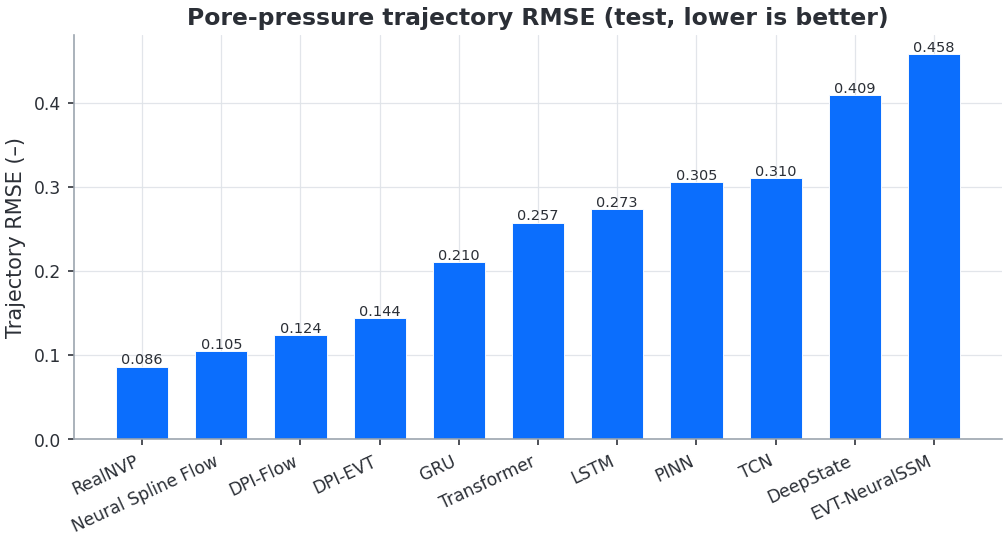

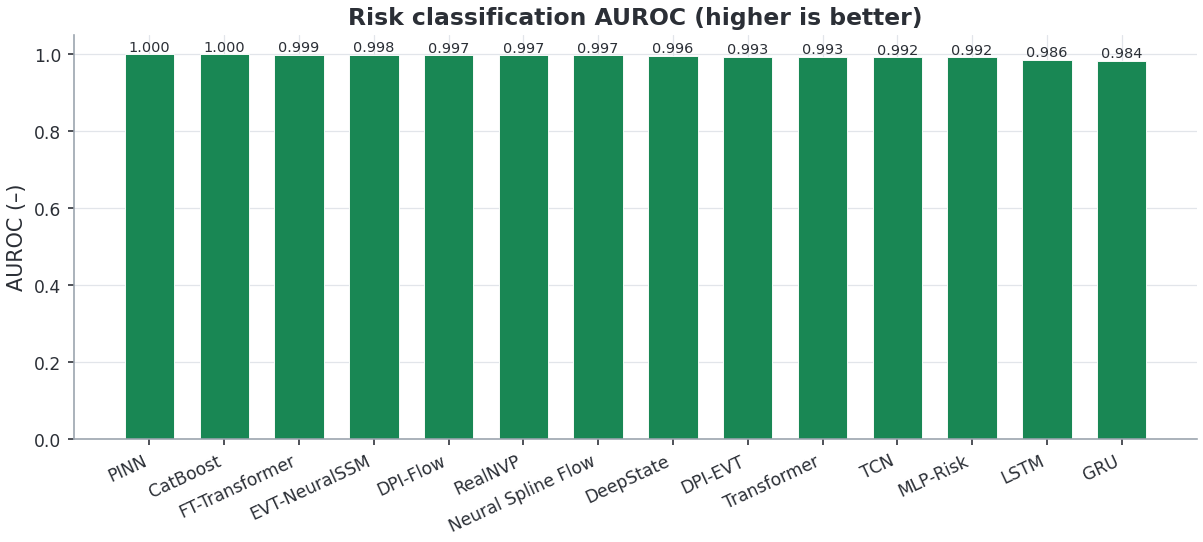

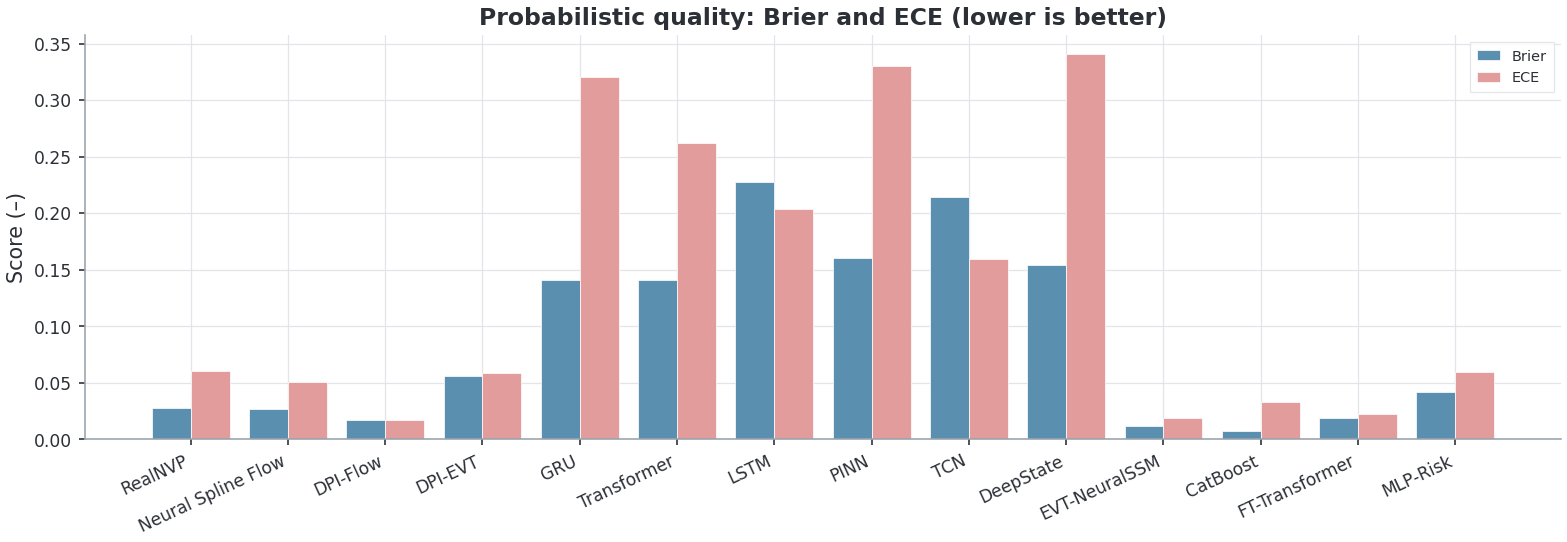

In [8]:
traj_df = leaderboard.dropna(subset=["Traj_RMSE"]).sort_values("Traj_RMSE")
bar(traj_df["model"], traj_df["Traj_RMSE"], title="Pore-pressure trajectory RMSE (test, lower is better)",
    ylabel="Trajectory RMSE (–)", color="#0b6efd", save=SAVE_FIGS, fig_id="3_1_leaderboard_rmse").show()
auc_df = leaderboard.sort_values("AUROC", ascending=False)
bar(auc_df["model"], auc_df["AUROC"], title="Risk classification AUROC (higher is better)",
    ylabel="AUROC (–)", color="#198754", save=SAVE_FIGS, fig_id="3_1_auroc").show()
grouped_bar(leaderboard["model"].tolist(),
            {"Brier": leaderboard["Brier"].tolist(), "ECE": leaderboard["ECE"].tolist()},
            title="Probabilistic quality: Brier and ECE (lower is better)", ylabel="Score (–)",
            save=SAVE_FIGS, fig_id="3_1_brier_ece").show()

## ROC curves

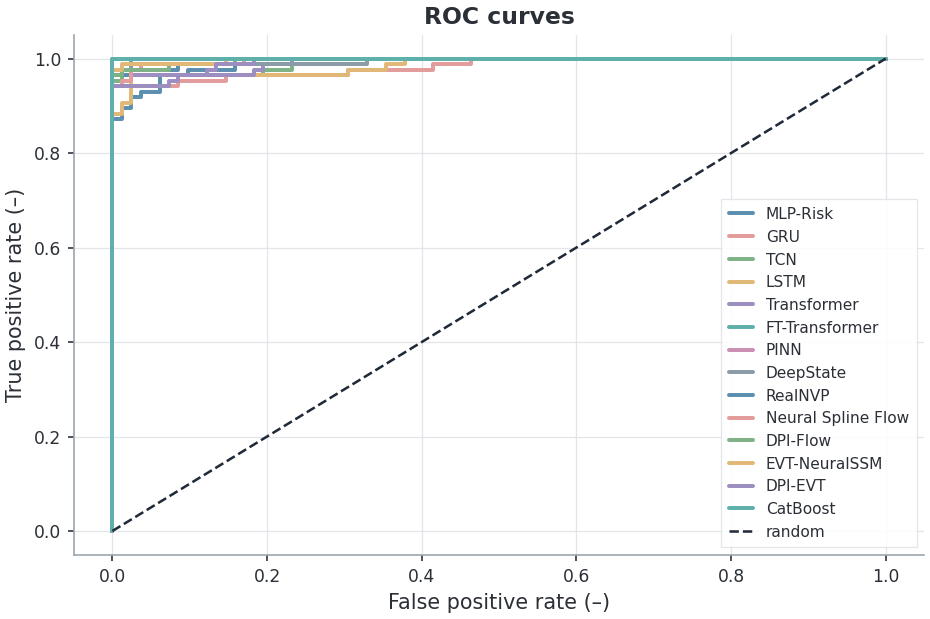

In [9]:
y_true = test["label"].cpu().numpy()
series = []
for disp, out in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, out["risk_prob"])
    series.append({"x": fpr, "y": tpr, "name": disp})
series.append({"x": [0, 1], "y": [0, 1], "name": "random", "color": "#1f2937", "dash": "dash", "width": 1.4})
lines(series, title="ROC curves", xlabel="False positive rate (–)", ylabel="True positive rate (–)",
      save=SAVE_FIGS, fig_id="3_1_roc_curves").show()

## Risk calibration

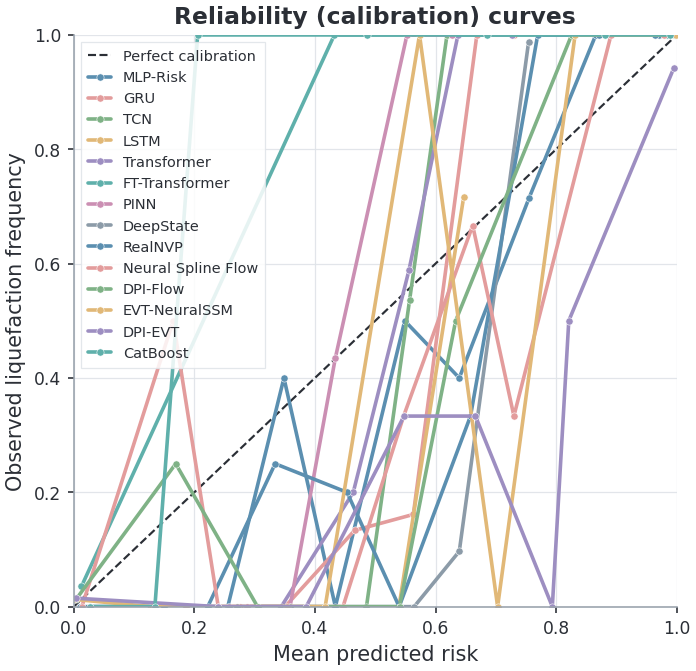

In [10]:
curves = {}
for disp in sample_tables:
    st = sample_tables[disp]
    if st["liq_label"].nunique() > 1:
        frac_pos, mean_pred = calibration_curve(st["liq_label"], st["risk_prob_pred"], n_bins=10)
        curves[disp] = (mean_pred, frac_pos)
calibration_plot(curves, title="Reliability (calibration) curves",
                 save=SAVE_FIGS, fig_id="3_1_calibration").show()

## Post-hoc temperature scaling

A single temperature T is fitted on the validation set per model and applied to the test
risk logits. This is a fair, universal post-hoc calibration step — it improves Brier/ECE
without changing AUROC (ranking is preserved).

,Model,T,Brier raw,Brier cal,ECE raw,ECE cal
0,MLP-Risk,1.06,0.0421,0.0427,0.0598,0.0653
1,GRU,0.80,0.1411,0.1268,0.3206,0.2571
2,TCN,0.37,0.2143,0.1808,0.1598,0.3176
3,LSTM,0.54,0.2276,0.2335,0.2041,0.1897
4,Transformer,0.34,0.1410,0.0645,0.2620,0.1824
5,FT-Transformer,1.27,0.0192,0.0192,0.0225,0.0232
6,PINN,0.46,0.1604,0.1027,0.3302,0.2586
7,DeepState,0.88,0.1540,0.1491,0.3406,0.3177
8,RealNVP,0.99,0.0277,0.0276,0.0607,0.0571
9,Neural Spline Flow,1.32,0.0264,0.0288,0.0503,0.0661


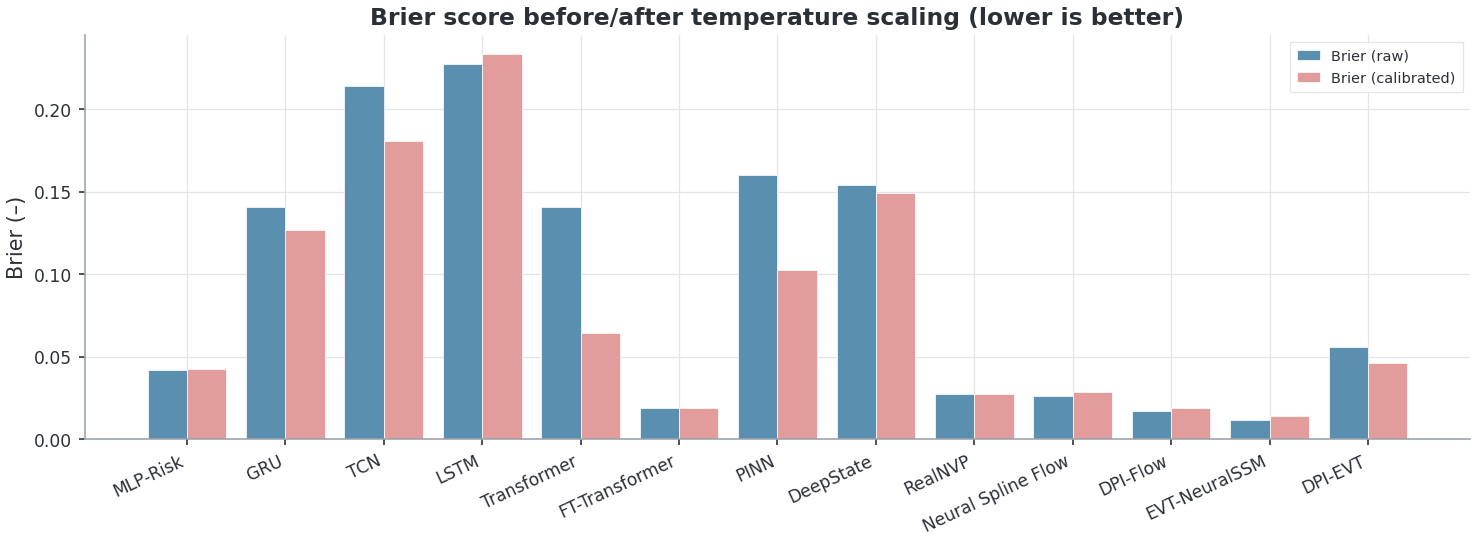

In [11]:
from liquefaction_ai.evaluation import fit_temperature, apply_temperature, expected_calibration_error, safe_binary_metrics

val = benchmark["val"]; y_val = val["label"].cpu().numpy(); y_test = test["label"].cpu().numpy()
cal_rows = []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name); disp = hp["display_name"]
    val_out = collect_outputs(model, val, config, device)
    vp = np.clip(val_out["risk_prob"], 1e-6, 1 - 1e-6); v_logit = np.log(vp / (1 - vp))
    T = fit_temperature(v_logit, y_val); T = float(np.clip(T if np.isfinite(T) else 1.0, 0.05, 20.0))
    p_raw = np.clip(np.nan_to_num(predictions[disp]["risk_prob"], nan=0.5), 1e-6, 1 - 1e-6)
    p_cal = np.clip(np.nan_to_num(apply_temperature(p_raw, T), nan=0.5), 1e-6, 1 - 1e-6)
    _, _, brier_raw = safe_binary_metrics(y_test, p_raw); ece_raw = expected_calibration_error(y_test, p_raw)
    _, _, brier_cal = safe_binary_metrics(y_test, p_cal); ece_cal = expected_calibration_error(y_test, p_cal)
    cal_rows.append({"Model": disp, "T": round(T, 2), "Brier raw": round(brier_raw, 4), "Brier cal": round(brier_cal, 4),
                     "ECE raw": round(ece_raw, 4), "ECE cal": round(ece_cal, 4)})
cal_df = pd.DataFrame(cal_rows)
display(cal_df)
grouped_bar(cal_df["Model"].tolist(), {"Brier (raw)": cal_df["Brier raw"].tolist(), "Brier (calibrated)": cal_df["Brier cal"].tolist()},
            title="Brier score before/after temperature scaling (lower is better)", ylabel="Brier (–)",
            save=SAVE_FIGS, fig_id="3_1_temperature_scaling").show()

## Uncertainty: coverage and interval width

,Model,Coverage@90%,Interval width@90%
0,RealNVP,0.7690,0.2314
1,Neural Spline Flow,0.7434,0.2474
2,DPI-Flow,0.8528,0.3431
3,DPI-EVT,0.8089,0.3730
4,GRU,0.9503,0.7972
5,Transformer,0.7889,0.6513
6,LSTM,0.8040,0.7149
7,PINN,0.6636,0.6281
8,TCN,0.7787,0.8448
9,DeepState,0.8078,0.9283


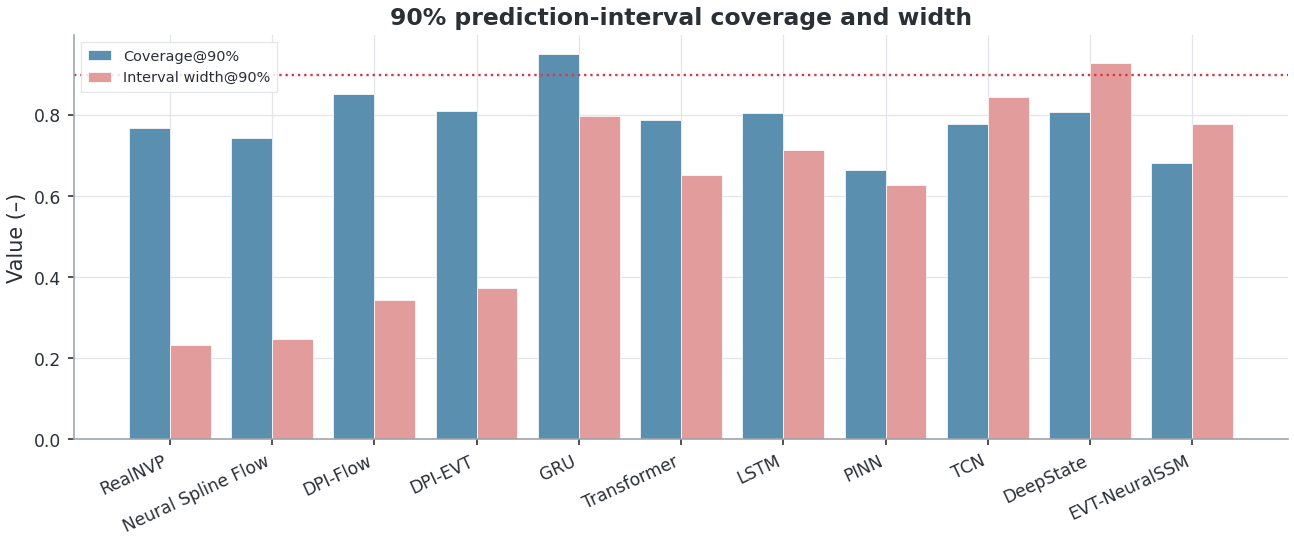

In [12]:
cov_df = leaderboard.dropna(subset=["Coverage_90"])[["model", "Coverage_90", "Interval_Width_90"]]
display(english_metric_table(cov_df).round(4))
fig = grouped_bar(cov_df["model"].tolist(),
                  {"Coverage@90%": cov_df["Coverage_90"].tolist(),
                   "Interval width@90%": cov_df["Interval_Width_90"].tolist()},
                  title="90% prediction-interval coverage and width", ylabel="Value (–)",
                  save=False, fig_id="3_1_coverage")
fig.add_hline(y=0.90, line_dash="dot", line_color="#dc3545")
from liquefaction_ai.viz import save_figure
save_figure(fig, "3_1_coverage", save=SAVE_FIGS)
fig.show()

## Итог

Структурированные модели дают CRR-границу, нулевые нарушения монотонности и осмысленную неопределённость; конкретные лидеры по CRPS, Brier, N_liq и CRR берутся из сохранённых таблиц этого ноутбука.
Дальше — **3.2 абляции и OOD**.
